In [15]:
from dotenv import load_dotenv

load_dotenv()

True

In [16]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [17]:
%pip install --upgrade --quiet yfinance

Note: you may need to restart the kernel to use updated packages.


In [18]:
from langgraph.graph import MessagesState
from langgraph.types import Command
from typing import Literal
from langchain_core.messages import HumanMessage

from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool

from langchain.agents import create_agent

market_research_agent = create_agent(
    llm,
    tools=[YahooFinanceNewsTool()],
    system_prompt='You are a market researcher. Provide fact only not opinions'
)

def market_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = market_research_agent.invoke(state)
    # print(f'Market research agent result: {result}')
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='market_research')]},
        goto='supervisor'
    )

In [19]:
%pip install pymysql

Note: you may need to restart the kernel to use updated packages.


In [20]:
import yfinance as yf

from langchain.tools import tool

@tool
def get_stock_price(ticker: str) -> dict:
    """Given a stock ticker, return the price data for the past month"""
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info

stock_research_tools = [get_stock_price]
stock_research_agent = create_agent(
    llm,
    tools=stock_research_tools,
    system_prompt='You are a stock researcher. Provide fact only not opinions'
)

def stock_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = stock_research_agent.invoke(state)
    # print(f'Stock research agent result: {result}')
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='stock_research')]},
        goto='supervisor'
    )

In [21]:
@tool
def company_research_tool(ticker: str) -> dict:
    """Given a ticker, return the financial information and SEC filings"""
    company_info = yf.Ticker(ticker)
    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()
    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_tools = [company_research_tool]
company_research_agent = create_agent(
    llm,
    tools=company_research_tools,
    system_prompt='You are a company researcher. Provide fact only not opinions'
)

def company_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = company_research_agent.invoke(state)
    # print(f'Company research agent result: {result}')
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='company_research')]},
        goto='supervisor'
    )

In [22]:
from langchain_core.prompts import PromptTemplate

analyst_prompt = PromptTemplate.from_template(
    """You are a stock market analyst. Given the following information, 
Please decide wheter to buy, sell, or hold the stock.

Information:
{messages}"""
)

analyst_chain = analyst_prompt | llm

def analyst_node(state: MessagesState):
    result = analyst_chain.invoke({'messages': state['messages'][1:]})

    return {'messages': [result]}

In [23]:
from typing import Literal
from pydantic import BaseModel, Field
from langgraph.graph import END

members = ["market_research", "stock_research", "company_research"]
options = Literal["market_research", "stock_research", "company_research", "FINISH"]

class Router(BaseModel):
    """Worker to route to next. If no workers needed, route to FINISH."""
    next: options = Field(
        description="The next worker to act, or FINISH when the task is complete"
    )

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

def supervisor_node(state: MessagesState) -> Command[Literal["market_research", "stock_research", "company_research", "__end__"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response.next
    if goto == "FINISH":
        goto = "analyst"
    return Command(goto=goto)


In [24]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_node("market_research", market_research_node)
graph_builder.add_node("stock_research", stock_research_node)
graph_builder.add_node("company_research", company_research_node)
graph_builder.add_node("analyst", analyst_node)

In [25]:
graph_builder.add_edge(START, "supervisor")
graph_builder.add_edge("analyst", END)
graph = graph_builder.compile()

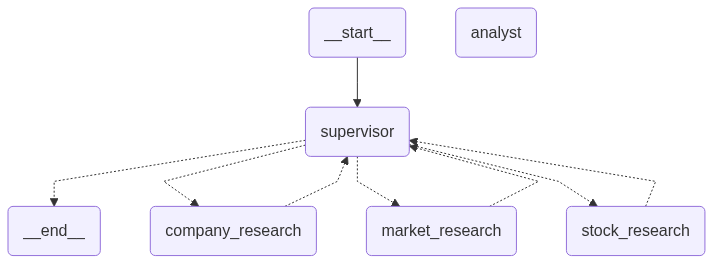

In [26]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
for chunk in graph.stream(
    {'messages': [('user', 'Provide factual research on Snowflake (ticker: SNOW): recent news, price data, and financials.')]}, stream_mode='values'
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Provide factual research on Snowflake (ticker: SNOW): recent news, price data, and financials.


[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================
Name: stock_research

[{'type': 'text', 'text': 'Here is the price data for Snowflake (SNOW) for the past month:\n\n**Closing Prices:**\n*   June 30, 2026: 254.5\n*   July 1, 2026: 261.19\n*   July 2, 2026: 260.15\n*   July 6, 2026: 262.09\n*   July 7, 2026: 262.74\n*   July 8, 2026: 261.31\n*   July 9, 2026: 267.49\n*   July 10, 2026: 261.45\n*   July 13, 2026: 268.65\n*   July 14, 2026: 275.94\n*   July 15, 2026: 271.87\n*   July 16, 2026: 270.02\n*   July 17, 2026: 268.90\n*   July 20, 2026: 274.34\n*   July 21, 2026: 271.73\n*   July 22, 2026: 267.80\n*   July 23, 2026: 265.13\n*   July 24, 2026: 268.06\n*   July 27, 2026: 272.92\n*   July 28, 2026: 270.36\n*   July 29, 2026: 282.90\n*   July 30, 2026: 289.52\n\n**Highest Prices:**\n*   July 29, 2026: 293.56\n*   July 30, 2026: 291.65\n\n**Lowest Prices:**\n*   June 30, 2026: 246.01\n*   July 9, 2026: 253.00\n\n**Opening Prices:**\n*   July 29, 2026: 2